# Notebook 05 — Delta-Embeddings ESM-2 (Zero-Shot)

Computes **delta-embeddings** for ESM-2 (`esm2_t33_650M_UR50D`) and evaluates them as a zero-shot pathogenicity predictor.

**Strategy:** For each variant, two forward passes are performed — one with the wild-type sequence and one with the mutant residue substituted at position `pos_protein`. The hidden-state vector at the mutated position is extracted from **layer 33** (last layer) in both passes. The delta-embedding is:

$$\Delta\varepsilon = \varepsilon_{mut} - \varepsilon_{wt}$$

The **L2 norm** of $\Delta\varepsilon$ is used as a scalar zero-shot pathogenicity score.

**Rationale:** A mutation that strongly displaces the residue's representation in the model's learned protein space is hypothesised to more severely perturb the evolutionary constraints captured during pre-training, and thus to be more likely pathogenic.

**Key methodological notes:**
- Input: `variants_with_scores.parquet` — already filtered (no 'X' residues, only evaluable genes with ≥5 variants and both classes)
- Window: 1024-residue centred window, identical to notebook 02
- Device: MPS (Apple M4 Max); no CUDA
- Output: `esm2_delta_norm` column added to parquet; `delta_gene_metrics.parquet` with per-gene ROC-AUC and PR-AUC

In [12]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon
from transformers import EsmModel, EsmTokenizer
from tqdm.auto import tqdm

from bio_var_pred.embeddings.assess import get_windowed_sequence
from bio_var_pred.embeddings.checkpoint import restore_np_checkpoint
from bio_var_pred.embeddings.setup import get_device
from bio_var_pred.metrics.compute import compute_delta_norm
from bio_var_pred.metrics.evaluate import evaluate_gene, assign_stratum
from bio_var_pred.utils.paths import PROCESSED_DATA_DIR

%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [7]:
DEVICE = get_device()

PyTorch version: 2.11.0
MPS available
Using device: mps


## 1. Load dataset

In [8]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "variants_with_scores.parquet")

print(f"Variants: {len(df):,}")
print(f"Genes: {df['gene'].nunique():,}")
df.head()

Variants: 54,821
Genes: 2,252


,id,chrom,pos_genomic,ref,alt,gene,transcript_id,pos_protein,aa_wt,aa_mut,label,protein_seq,af,ac,an,log_af,esm2_log_ratio,prott5_log_ratio,esm2_delta_norm,prott5_delta_norm
0,387476,1,1020183,G,C,AGRN,ENST00000379370,4,R,P,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.000994,1176.0,1182524.0,-3.002398,-3.081203,1.521034,4.189582,2.018191
1,263204,1,1041218,C,T,AGRN,ENST00000379370,258,T,I,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001124,1484.0,1319880.0,-2.949098,-6.396329,-2.463169,3.355133,0.904710
2,128291,1,1041583,A,G,AGRN,ENST00000379370,353,Q,R,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001738,2529.0,1454750.0,-2.759838,-1.381803,1.796480,3.731554,0.994419
3,263158,1,1041648,G,T,AGRN,ENST00000379370,375,A,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.006713,9794.0,1458968.0,-2.173085,-5.311023,-0.940014,3.296486,0.753585
4,263163,1,1043382,G,A,AGRN,ENST00000379370,510,G,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.010539,15353.0,1456748.0,-1.977192,-5.103392,15.489303,4.023306,1.071313


In [9]:
# Sanity checks
assert df["protein_seq"].str.contains("X").sum() == 0, \
    "Sequences with 'X' should have been filtered in notebook 02/03"

assert df["label"].isin([0, 1]).all(), "Labels must be binary"

# Confirm 1-based indexing: wt residue at pos_protein - 1
mismatch = df.apply(
    lambda r: r["protein_seq"][r["pos_protein"] - 1] != r["aa_wt"], axis=1
).sum()
assert mismatch == 0, f"{mismatch} wt residue mismatches found"

print("All sanity checks passed.")

All sanity checks passed.


## 2. Load ESM-2 model

Using `EsmModel` (not `EsmForMaskedLM`) because we need hidden states, not logits.

In [10]:
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
HF_TOKEN = os.environ.get("HF_TOKEN")

LAYER = 33  # last layer; 1-indexed in ESM-2 output (index 32 in hidden_states tuple)
WINDOW_SIZE = 1024

tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
model = EsmModel.from_pretrained(MODEL_NAME, output_hidden_states=True, token=HF_TOKEN)
model.eval()
model.to(DEVICE)

print(f"Model loaded: {MODEL_NAME}")
print(f"Extracting hidden states from layer {LAYER}")

Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: facebook/esm2_t33_650M_UR50D
Extracting hidden states from layer 33


In [13]:
sample = df.sample(5, random_state=42)

for _, row in sample.iterrows():
    seq_w, pos_w = get_windowed_sequence(row["protein_seq"], row["pos_protein"])
    inputs = tokenizer(seq_w, return_tensors="pt", add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    print(f"id={row['id']}  pos_protein={row['pos_protein']}  aa_wt={row['aa_wt']}")
    print(f"  windowed pos: {pos_w}")
    print(f"  token at index pos_w ({pos_w}): {tokens[pos_w]}")
    print(f"  expected wt residue: {row['aa_wt']}")
    print()

id=549081  pos_protein=811  aa_wt=C
  windowed pos: 513
  token at index pos_w (513): C
  expected wt residue: C

id=4087094  pos_protein=69  aa_wt=A
  windowed pos: 69
  token at index pos_w (69): A
  expected wt residue: A

id=95075  pos_protein=31  aa_wt=T
  windowed pos: 31
  token at index pos_w (31): T
  expected wt residue: T

id=321000  pos_protein=2974  aa_wt=M
  windowed pos: 513
  token at index pos_w (513): M
  expected wt residue: M

id=456836  pos_protein=130  aa_wt=G
  windowed pos: 130
  token at index pos_w (130): G
  expected wt residue: G



## 3. Delta-embedding extraction


### 3.1 Inference loop with checkpointing

Two forward passes per variant (wt + mut) means ~2× the compute cost of notebook 02.
A checkpoint is saved every 500 variants so inference can be resumed if interrupted.

In [11]:
CHECKPOINT_PATH = PROCESSED_DATA_DIR / "delta_norms_esm2_checkpoint.npy"
CHECKPOINT_INTERVAL = 500

n = len(df)

# Load checkpoint if it exists
delta_norms, start_idx = restore_np_checkpoint(CHECKPOINT_PATH, n)

# Inference
for i, (_, row) in enumerate(
    tqdm(df.iloc[start_idx:].iterrows(), total=n - start_idx, desc="Delta-embeddings")
):
    try:
        norm = compute_delta_norm(row, model, tokenizer, DEVICE)
    except Exception as e:
        print(f"\nError at index {start_idx + i} (id={row['id']}): {e}")
        norm = np.nan

    delta_norms.append(norm)

    # Periodic checkpoint
    if (len(delta_norms)) % CHECKPOINT_INTERVAL == 0:
        np.save(CHECKPOINT_PATH, np.array(delta_norms))

# Final checkpoint
np.save(CHECKPOINT_PATH, np.array(delta_norms))
print(f"\nDone. {sum(np.isnan(delta_norms))} NaNs out of {len(delta_norms)} variants.")

Starting fresh inference


Delta-embeddings:   0%|          | 0/54821 [00:00<?, ?it/s]


Done. 0 NaNs out of 54821 variants.


### 3.3 Attach scores to dataframe

In [12]:
assert len(delta_norms) == len(df), \
    f"Length mismatch: {len(delta_norms)} scores vs {len(df)} variants"

df["esm2_delta_norm"] = np.array(delta_norms, dtype=np.float32)

print(f"esm2_delta_norm — non-null: {df['esm2_delta_norm'].notna().sum():,}")
df["esm2_delta_norm"].describe()

esm2_delta_norm — non-null: 54,821


count    54821.000000
mean         3.586709
std          0.705289
min          0.575556
25%          3.171703
50%          3.607200
75%          4.014363
max         10.313895
Name: esm2_delta_norm, dtype: float64

In [13]:
# Save updated parquet
out_path = PROCESSED_DATA_DIR / "variants_with_scores.parquet"
df.to_parquet(out_path)
print(f"Saved to {out_path}")
print(f"Columns: {df.columns.tolist()}")

Saved to /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/variants_with_scores.parquet
Columns: ['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio', 'prott5_log_ratio', 'esm2_delta_norm']


## 4. Zero-shot evaluation — per-gene ROC-AUC and PR-AUC

Mirrors the evaluation protocol of notebook 04 exactly.
Only genes where `esm2_delta_norm` is non-null for all variants are evaluated.

In [16]:
records = []

for gene, grp in df.groupby("gene"):
    result = evaluate_gene(grp, "esm2_delta_norm")
    if result is not None:
        result["gene"] = gene
        records.append(result)

delta_metrics = pd.DataFrame(records)
delta_metrics["prevalence"] = delta_metrics["n_pathogenic"] / delta_metrics["n_variants"]

delta_metrics["stratum"] = delta_metrics["n_variants"].apply(assign_stratum)

print(f"Genes evaluated: {len(delta_metrics):,}")
print(f"Variants covered: {delta_metrics['n_variants'].sum():,}")
delta_metrics.head()

Genes evaluated: 2,252
Variants covered: 54,821


,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,gene,prevalence,stratum
0,0.500000,0.333333,5,1,4,A4GALT,0.200000,5–10
1,0.177778,0.506896,14,9,5,AAAS,0.642857,11–50
2,0.571429,0.699969,15,7,8,AARS1,0.466667,11–50
3,0.500000,0.498219,22,10,12,AARS2,0.454545,11–50
4,0.375000,0.416667,6,2,4,AASS,0.333333,5–10


## 5. Global metrics

In [17]:
roc_med  = delta_metrics["roc_auc"].median()
roc_iqr  = delta_metrics["roc_auc"].quantile([0.25, 0.75]).values
prauc_med = delta_metrics["pr_auc"].median()
prauc_iqr = delta_metrics["pr_auc"].quantile([0.25, 0.75]).values

print("=== ESM-2 Delta-Norm (Zero-Shot) ===")
print(f"ROC-AUC  median: {roc_med:.3f}  IQR: [{roc_iqr[0]:.3f}, {roc_iqr[1]:.3f}]")
print(f"PR-AUC   median: {prauc_med:.3f}  IQR: [{prauc_iqr[0]:.3f}, {prauc_iqr[1]:.3f}]")

=== ESM-2 Delta-Norm (Zero-Shot) ===
ROC-AUC  median: 0.450  IQR: [0.250, 0.625]
PR-AUC   median: 0.591  IQR: [0.310, 0.841]


## 6. Comparison with ESM-2 log-ratio

Load `zeroshot_gene_metrics.parquet` (notebook 04) and merge for a direct comparison.

In [18]:
logr_metrics = pd.read_parquet(
    PROCESSED_DATA_DIR / "zeroshot_gene_metrics.parquet"
)[["gene", "roc_auc", "pr_auc"]].rename(
    columns={"roc_auc": "roc_auc_logr", "pr_auc": "pr_auc_logr"}
)

comparison = delta_metrics.merge(logr_metrics, on="gene", how="inner")
print(f"Genes in common: {len(comparison):,}")
comparison.head()

Genes in common: 2,252


,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,gene,prevalence,stratum,roc_auc_logr,pr_auc_logr
0,0.500000,0.333333,5,1,4,A4GALT,0.200000,5–10,0.750000,0.500000
1,0.177778,0.506896,14,9,5,AAAS,0.642857,11–50,0.822222,0.930014
2,0.571429,0.699969,15,7,8,AARS1,0.466667,11–50,0.982143,0.982143
3,0.500000,0.498219,22,10,12,AARS2,0.454545,11–50,0.916667,0.913929
4,0.375000,0.416667,6,2,4,AASS,0.333333,5–10,0.625000,0.700000


In [19]:
# Wilcoxon signed-rank test: delta-norm vs log-ratio, ROC-AUC
stat, p = wilcoxon(comparison["roc_auc"], comparison["roc_auc_logr"])

print("=== Wilcoxon signed-rank: ROC-AUC (delta-norm vs log-ratio) ===")
print(f"Statistic: {stat:.2f}   p-value: {p:.3e}")

delta_better = (comparison["roc_auc"] > comparison["roc_auc_logr"]).sum()
logr_better  = (comparison["roc_auc"] < comparison["roc_auc_logr"]).sum()
print(f"Delta-norm better in {delta_better} genes; log-ratio better in {logr_better} genes")

=== Wilcoxon signed-rank: ROC-AUC (delta-norm vs log-ratio) ===
Statistic: 104857.00   p-value: 8.636e-289
Delta-norm better in 194 genes; log-ratio better in 1939 genes


## 7. Correlations

In [20]:
# ROC-AUC vs gene size
rho_size, p_size = stats.spearmanr(
    delta_metrics["n_variants"], delta_metrics["roc_auc"]
)
print(f"ROC-AUC vs gene size:   Spearman ρ = {rho_size:.3f}  p = {p_size:.2e}")

# PR-AUC vs prevalence
rho_prev, p_prev = stats.spearmanr(
    delta_metrics["prevalence"], delta_metrics["pr_auc"]
)
print(f"PR-AUC  vs prevalence:  Spearman ρ = {rho_prev:.3f}  p = {p_prev:.2e}")

# ROC-AUC vs prevalence (should be ~0, as in notebook 04)
rho_roc_prev, p_roc_prev = stats.spearmanr(
    delta_metrics["prevalence"], delta_metrics["roc_auc"]
)
print(f"ROC-AUC vs prevalence:  Spearman ρ = {rho_roc_prev:.3f}  p = {p_roc_prev:.2e}")

ROC-AUC vs gene size:   Spearman ρ = -0.028  p = 1.83e-01
PR-AUC  vs prevalence:  Spearman ρ = 0.745  p = 0.00e+00
ROC-AUC vs prevalence:  Spearman ρ = 0.014  p = 5.20e-01


## 8. Figures

In [21]:
FIGURE_DIR = PROCESSED_DATA_DIR
STRAT_ORDER = ["5–10", "11–50", ">50"]
STRAT_COLORS = ["#4393c3", "#2166ac", "#053061"]

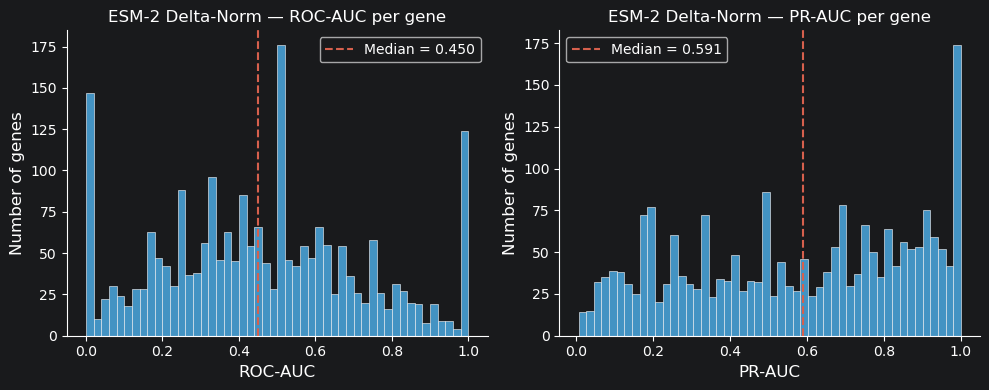

Saved fig_delta_auc_distributions.pdf


In [22]:
# ── Fig 1: ROC-AUC and PR-AUC distributions (delta-norm) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(
    axes,
    ["roc_auc", "pr_auc"],
    ["ROC-AUC", "PR-AUC"]
):
    ax.hist(delta_metrics[col].dropna(), bins=50, color="#4393c3", edgecolor="white", linewidth=0.4)
    med = delta_metrics[col].median()
    ax.axvline(med, color="#d6604d", linewidth=1.5, linestyle="--", label=f"Median = {med:.3f}")
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Number of genes", fontsize=12)
    ax.set_title(f"ESM-2 Delta-Norm — {label} per gene", fontsize=12)
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_auc_distributions.pdf", dpi=150)
plt.show()
print("Saved fig_delta_auc_distributions.pdf")

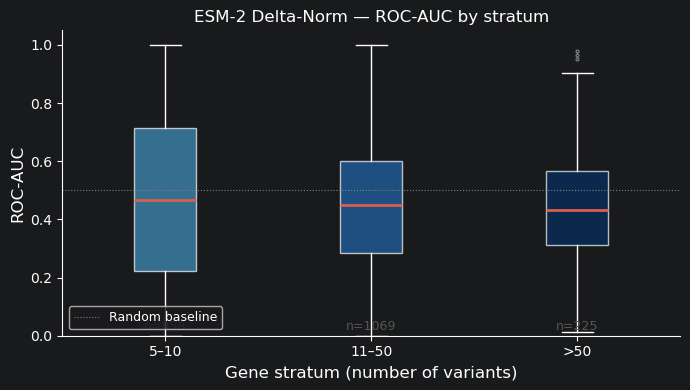

Saved fig_delta_auc_by_stratum.pdf


In [24]:
# ── Fig 2: ROC-AUC by stratum (boxplot) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

data_by_stratum = [
    delta_metrics.loc[delta_metrics["stratum"] == s, "roc_auc"].dropna().values
    for s in STRAT_ORDER
]

bp = ax.boxplot(
    data_by_stratum,
    tick_labels=STRAT_ORDER,
    patch_artist=True,
    medianprops=dict(color="#d6604d", linewidth=2),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    flierprops=dict(marker="o", markersize=2, alpha=0.4),
)

for patch, color in zip(bp["boxes"], STRAT_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel("Gene stratum (number of variants)", fontsize=12)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("ESM-2 Delta-Norm — ROC-AUC by stratum", fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle=":", label="Random baseline")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Annotate with n genes
for i, s in enumerate(STRAT_ORDER):
    n_genes = (delta_metrics["stratum"] == s).sum()
    ax.text(i + 1, 0.02, f"n={n_genes}", ha="center", fontsize=9, color="#555")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_auc_by_stratum.pdf", dpi=150)
plt.show()
print("Saved fig_delta_auc_by_stratum.pdf")

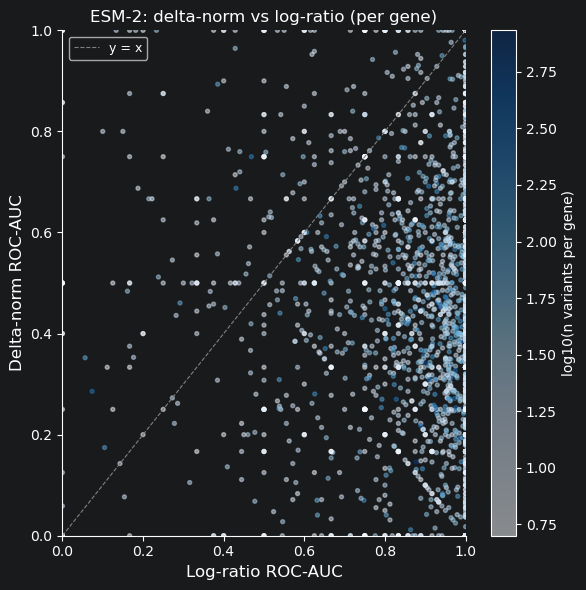

Saved fig_delta_vs_logr_scatter.pdf


In [25]:
# ── Fig 3: Scatter — delta-norm ROC-AUC vs log-ratio ROC-AUC ────────────────
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    comparison["roc_auc_logr"],
    comparison["roc_auc"],
    c=np.log10(comparison["n_variants"]),
    cmap="Blues",
    alpha=0.5,
    s=8,
    rasterized=True,
)
plt.colorbar(sc, ax=ax, label="log10(n variants per gene)")

# Diagonal reference
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=0.8, label="y = x")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Log-ratio ROC-AUC", fontsize=12)
ax.set_ylabel("Delta-norm ROC-AUC", fontsize=12)
ax.set_title("ESM-2: delta-norm vs log-ratio (per gene)", fontsize=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_vs_logr_scatter.pdf", dpi=150)
plt.show()
print("Saved fig_delta_vs_logr_scatter.pdf")

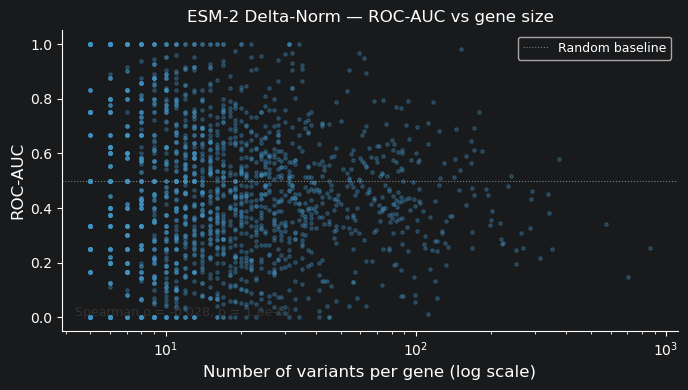

Saved fig_delta_roc_vs_genesize.pdf


In [26]:
# ── Fig 4: ROC-AUC vs gene size (delta-norm) ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(
    delta_metrics["n_variants"],
    delta_metrics["roc_auc"],
    alpha=0.3,
    s=6,
    color="#4393c3",
    rasterized=True,
)
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle=":", label="Random baseline")
ax.set_xscale("log")
ax.set_xlabel("Number of variants per gene (log scale)", fontsize=12)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("ESM-2 Delta-Norm — ROC-AUC vs gene size", fontsize=12)
ax.text(
    0.02, 0.05,
    f"Spearman ρ = {rho_size:.3f}, p = {p_size:.1e}",
    transform=ax.transAxes, fontsize=9, color="#333"
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_roc_vs_genesize.pdf", dpi=150)
plt.show()
print("Saved fig_delta_roc_vs_genesize.pdf")

## 9. Save per-gene metrics

In [27]:
metrics_path = PROCESSED_DATA_DIR / "delta_gene_metrics_esm2.parquet"
delta_metrics.to_parquet(metrics_path, index=False)
print(f"Saved {metrics_path}")
print(f"Columns: {delta_metrics.columns.tolist()}")
delta_metrics.describe()

Saved /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/delta_gene_metrics.parquet
Columns: ['roc_auc', 'pr_auc', 'n_variants', 'n_pathogenic', 'n_benign', 'gene', 'prevalence', 'stratum']


,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,prevalence
count,2252.000000,2252.000000,2252.00000,2252.000000,2252.000000,2252.000000
mean,0.456116,0.571171,24.34325,13.154973,11.188277,0.469848
std,0.265851,0.296118,43.31664,34.755418,23.844530,0.288987
min,0.000000,0.006410,5.00000,1.000000,1.000000,0.004587
25%,0.250000,0.309524,7.00000,2.000000,3.000000,0.200000
50%,0.449750,0.590769,12.00000,4.000000,6.000000,0.428571
75%,0.625000,0.840720,23.00000,11.000000,11.000000,0.750000
max,1.000000,1.000000,859.00000,836.000000,675.000000,0.988539


In [2]:
eval_df = pd.read_parquet(PROCESSED_DATA_DIR / "delta_gene_metrics_esm2.parquet")
eval_df.describe()

,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,prevalence
count,2252.000000,2252.000000,2252.00000,2252.000000,2252.000000,2252.000000
mean,0.456116,0.571171,24.34325,13.154973,11.188277,0.469848
std,0.265851,0.296118,43.31664,34.755418,23.844530,0.288987
min,0.000000,0.006410,5.00000,1.000000,1.000000,0.004587
25%,0.250000,0.309524,7.00000,2.000000,3.000000,0.200000
50%,0.449750,0.590769,12.00000,4.000000,6.000000,0.428571
75%,0.625000,0.840720,23.00000,11.000000,11.000000,0.750000
max,1.000000,1.000000,859.00000,836.000000,675.000000,0.988539


In [5]:
eval_df.groupby("gene").describe()

roc_auc                                                        \
         count      mean std       min       25%       50%       75%   
gene                                                                   
A4GALT     1.0  0.500000 NaN  0.500000  0.500000  0.500000  0.500000   
AAAS       1.0  0.177778 NaN  0.177778  0.177778  0.177778  0.177778   
AARS1      1.0  0.571429 NaN  0.571429  0.571429  0.571429  0.571429   
AARS2      1.0  0.500000 NaN  0.500000  0.500000  0.500000  0.500000   
AASS       1.0  0.375000 NaN  0.375000  0.375000  0.375000  0.375000   
...        ...       ...  ..       ...       ...       ...       ...   
ZNF469     1.0  0.546341 NaN  0.546341  0.546341  0.546341  0.546341   
ZNF644     1.0  0.500000 NaN  0.500000  0.500000  0.500000  0.500000   
ZNF687     1.0  1.000000 NaN  1.000000  1.000000  1.000000  1.000000   
ZP3        1.0  0.625000 NaN  0.625000  0.625000  0.625000  0.625000   
ZSWIM6     1.0  0.100000 NaN  0.100000  0.100000  0.100000  0.100000   

                 pr_auc            ... n_benign       prevalence            \
             max  count      mean  ...      75%   max      count      mean   
gene                               ...                                       
A4GALT  0.500000    1.0  0.333333  ...      4.0   4.0        1.0  0.200000   
AAAS    0.177778    1.0  0.506896  ...      5.0   5.0        1.0  0.642857   
AARS1   0.571429    1.0  0.699969  ...      8.0   8.0        1.0  0.466667   
AARS2   0.500000    1.0  0.498219  ...     12.0  12.0        1.0  0.454545   
AASS    0.375000    1.0  0.416667  ...      4.0   4.0        1.0  0.333333   
...          ...    ...       ...  ...      ...   ...        ...       ...   
ZNF469  0.546341    1.0  0.095378  ...     82.0  82.0        1.0  0.057471   
ZNF644  0.500000    1.0  0.611111  ...      7.0   7.0        1.0  0.222222   
ZNF687  1.000000    1.0  1.000000  ...      8.0   8.0        1.0  0.111111   
ZP3     0.625000    1.0  0.392857  ...      8.0   8.0        1.0  0.200000   
ZSWIM6  0.100000    1.0  0.027027  ...     40.0  40.0        1.0  0.024390   

                                                              
       std       min       25%       50%       75%       max  
gene                                                          
A4GALT NaN  0.200000  0.200000  0.200000  0.200000  0.200000  
AAAS   NaN  0.642857  0.642857  0.642857  0.642857  0.642857  
AARS1  NaN  0.466667  0.466667  0.466667  0.466667  0.466667  
AARS2  NaN  0.454545  0.454545  0.454545  0.454545  0.454545  
AASS   NaN  0.333333  0.333333  0.333333  0.333333  0.333333  
...     ..       ...       ...       ...       ...       ...  
ZNF469 NaN  0.057471  0.057471  0.057471  0.057471  0.057471  
ZNF644 NaN  0.222222  0.222222  0.222222  0.222222  0.222222  
ZNF687 NaN  0.111111  0.111111  0.111111  0.111111  0.111111  
ZP3    NaN  0.200000  0.200000  0.200000  0.200000  0.200000  
ZSWIM6 NaN  0.024390  0.024390  0.024390  0.024390  0.024390  

[2252 rows x 48 columns]

In [14]:
print((1 - eval_df["roc_auc"]).median())

0.5502499637733662
